# Retail Portfolio Loss Estimation & Risk Strategy for Unsecured Lending

Project Overview

This project focuses on building a risk framework to estimate probability of default (pd) using borrower level behavioral and credit variables. logistic regression was used for modeling, and the classification threshold was adjusted to better capture high risk accounts. expected loss (el) was then calculated using pd along with ead and lgd, and the portfolio was analyzed across segments to understand risk distribution. stress testing was performed by worsening key variables like delinquencies, utilization, dti and credit score to evaluate how losses increase under adverse conditions.

### Table Of Contents
1. [Data Wrangling](#Data-Wrangling)
2. [Model Building](#Model-Building)
3. [Expected Loss (EL) Analysis](#Expected-Loss-(EL)-Analysis)
4. [Portfolio Stress Testing](#Portfolio-Stress-Testing)

In [ ]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (classification_report, roc_auc_score)
import sklearn.metrics as metrics

import warnings
warnings.filterwarnings('ignore')

In [1060]:
# Load Data
og_data = pd.read_csv('prosperLoanData.csv')
pd.set_option('display.max_columns', None)

In [1061]:
# Duplicate Check
print(og_data["LoanNumber"].nunique())
print(og_data.shape[0])

113066
113937


In [1062]:
loan_clean = og_data.drop_duplicates(subset="LoanNumber", keep="last").reset_index(drop=True)

In [1063]:
print(loan_clean["LoanNumber"].nunique())
print(loan_clean.shape)

113066
(113066, 81)


# Data Wrangling

In [1064]:
# Creating customized index for Accurate merging of output data
loan_clean = loan_clean.set_index("LoanNumber")

In [1065]:
data = loan_clean.copy()

In [1066]:
# Date Conversion

data['LoanOriginationDate'] = pd.to_datetime(data['LoanOriginationDate'])

In [1067]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113066 entries, 19141 to 127508
Data columns (total 80 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   ListingKey                           113066 non-null  object        
 1   ListingNumber                        113066 non-null  int64         
 2   ListingCreationDate                  113066 non-null  object        
 3   CreditGrade                          28953 non-null   object        
 4   Term                                 113066 non-null  int64         
 5   LoanStatus                           113066 non-null  object        
 6   ClosedDate                           55076 non-null   object        
 7   BorrowerAPR                          113041 non-null  float64       
 8   BorrowerRate                         113066 non-null  float64       
 9   LenderYield                          113066 non-null  float64       
 1

In [1068]:
data['Loan_Org_year'] = data['LoanOriginationDate'].dt.year
data['Loan_Org_month'] = data['LoanOriginationDate'].dt.month

In [1069]:
# Since some of the key variables are missing for the early years, we will focus on loans originated from 2010 onwards for our analysis.
data = data[data['Loan_Org_year'] >= 2010]

In [1070]:
data

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,DateCreditPulled,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors,Loan_Org_year,Loan_Org_month
LoanNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
134815,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,0.07960,0.0249,0.05470,6.0,A,7.0,2,CO,Professional,Employed,44.0,False,False,NaN,2014-02-27 08:28:14,680.0,699.0,1996-03-18 00:00:00,14.0,14.0,29.0,13,389.0,3.0,5.0,0.0,0.0,0.0,1.0,0.0,3989.0,0.21,10266.0,29.0,1.00,2.0,0.18,"$50,000-74,999",True,6125.000000,9E3B37071505919926B1D82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,10000,2014-03-03,Q1 2014,1D13370546739025387B2F4,318.93,0.0000,0.00,0.0000,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1,2014,3
77296,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,0.08490,0.0249,0.06000,6.0,A,9.0,16,GA,Skilled Labor,Employed,113.0,True,False,NaN,2012-10-22 11:02:32,800.0,819.0,1983-02-28 00:00:00,5.0,5.0,29.0,7,115.0,0.0,1.0,4.0,10056.0,14.0,0.0,0.0,1444.0,0.04,30754.0,26.0,0.76,0.0,0.15,"$25,000-49,999",True,2875.000000,A0393664465886295619C51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,16,10000,2012-11-01,Q4 2012,9ADE356069835475068C6D2,321.45,5143.2000,4091.09,1052.1100,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158,2012,11
102670,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,0.18316,0.0925,0.09066,3.0,D,4.0,2,MN,Executive,Employed,44.0,True,False,NaN,2013-09-14 18:38:44,680.0,699.0,2004-02-20 00:00:00,19.0,19.0,49.0,6,220.0,1.0,9.0,0.0,0.0,0.0,0.0,0.0,6193.0,0.81,695.0,39.0,0.95,2.0,0.26,"$100,000+",True,9583.333333,A180369302188889200689E,1.0,11.0,11.0,0.0,0.0,11000.0,9947.90,NaN,0,NaN,6,15000,2013-09-20,Q3 2013,36CE356043264555721F06C,563.97,2819.8500,1563.22,1256.6300,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20,2013,9
123257,0F05359734824199381F61D,1074836,2013-12-14 08:26:37.093000000,NaN,60,Current,NaN,0.15425,0.1314,0.1214,0.11567,0.0449,0.07077,5.0,B,10.0,1,NM,Professional,Employed,82.0,True,False,NaN,2013-12-14 08:26:40,740.0,759.0,1973-03-01 00:00:00,21.0,17.0,49.0,13,1410.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,62999.0,0.39,86509.0,47.0,1.00,0.0,0.36,"$100,000+",True,8333.333333,C3D63702273952547E79520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,3,15000,2013-12-24,Q4 2013,874A3701157341738DE458F,342.37,679.3400,351.89,327.4500,-25.33,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1,2013,12
88353,0F0A3576754255009D63151,750899,2013-04-12 09:52:56

In [1071]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82079 entries, 134815 to 127508
Data columns (total 82 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   ListingKey                           82079 non-null  object        
 1   ListingNumber                        82079 non-null  int64         
 2   ListingCreationDate                  82079 non-null  object        
 3   CreditGrade                          0 non-null      object        
 4   Term                                 82079 non-null  int64         
 5   LoanStatus                           82079 non-null  object        
 6   ClosedDate                           24089 non-null  object        
 7   BorrowerAPR                          82079 non-null  float64       
 8   BorrowerRate                         82079 non-null  float64       
 9   LenderYield                          82079 non-null  float64       
 10  Estimated

In [1072]:
# Selecting relevant columns for analysis
loan = data[[
    # Identity & Timeline
    'LoanOriginationDate',        
    'LoanOriginationQuarter',
    'Loan_Org_year',              
    'Loan_Org_month',             
    'Term',
    'LoanMonthsSinceOrigination',
    'LoanStatus',
    'LoanCurrentDaysDelinquent',
    'LoanFirstDefaultedCycleNumber',  
    'ClosedDate',
    'LoanOriginalAmount',
    'LP_CustomerPrincipalPayments',
    'LP_GrossPrincipalLoss',
    'LP_NetPrincipalLoss',
    'LP_NonPrincipalRecoverypayments',
    'EstimatedLoss',
    'MonthlyLoanPayment',
    'ProsperRating (Alpha)',
    'ProsperRating (numeric)',
    'ProsperScore',
    'CreditScoreRangeLower',
    'DebtToIncomeRatio',           
    'BankcardUtilization',
    'InquiriesLast6Months',
    'CurrentDelinquencies',
    'DelinquenciesLast7Years',
    'RevolvingCreditBalance',
    'TotalInquiries',
    'TradesNeverDelinquent (percentage)',
    'PublicRecordsLast10Years',
    'StatedMonthlyIncome',
    'EmploymentStatus',
    'ListingCategory (numeric)',
    'IncomeRange',
    'IsBorrowerHomeowner',
]].copy()

print(loan.shape)
print(loan.isnull().sum()[loan.isnull().sum() > 0])

(82079, 35)
LoanFirstDefaultedCycleNumber    76130
ClosedDate                       57990
EstimatedLoss                       73
ProsperRating (Alpha)               73
ProsperRating (numeric)             73
ProsperScore                        73
DebtToIncomeRatio                 7027
dtype: int64


In [1073]:
# Dropping the 73 rows missing ProsperRating
loan = loan.dropna(subset=['ProsperRating (Alpha)', 'ProsperScore'])

# Filling missing DTI by rating median
loan['DebtToIncomeRatio'] = loan.groupby('ProsperRating (Alpha)')['DebtToIncomeRatio'].transform(lambda x: x.fillna(x.median()))
                                
print(loan.shape)
print(loan.isnull().sum()[loan.isnull().sum() > 0])

(82006, 35)
LoanFirstDefaultedCycleNumber    76061
ClosedDate                       57990
dtype: int64


In [1074]:
# Target vairable values
data['LoanStatus'].value_counts()

LoanStatus
Current                   55730
Completed                 18047
Chargedoff                 5112
Defaulted                   930
Past Due (1-15 days)        800
Past Due (31-60 days)       361
Past Due (61-90 days)       311
Past Due (91-120 days)      304
Past Due (16-30 days)       265
FinalPaymentInProgress      203
Past Due (>120 days)         16
Name: count, dtype: int64

In [1075]:
# Loan Default status 
loan['is_default'] = loan['LoanStatus'].isin(
    ['Chargedoff', 'Defaulted', 'Past Due (91-120 days)', 'Past Due (>120 days)']
).astype(int)

In [1076]:
loan['is_default'].value_counts()

is_default
0    75648
1     6358
Name: count, dtype: int64

In [1077]:
# DPD Bucket calculation
def assign_dpd_bucket(row):
    if row['is_default'] == 1:
        return 'E_NPA'
    dpd = row['LoanCurrentDaysDelinquent']
    if dpd == 0:
        return 'A_Current'
    elif dpd <= 30:
        return 'B1_1-30'
    elif dpd <= 60:
        return 'B2_31-60'
    elif dpd <= 90:
        return 'B3_61-90'
    elif dpd > 90:
        return 'B4_90+'
    
loan['dpd_bucket'] = loan.apply(assign_dpd_bucket, axis=1)
loan['dpd_bucket'].value_counts()

dpd_bucket
A_Current    73911
E_NPA         6358
B1_1-30       1065
B2_31-60       361
B3_61-90       311
Name: count, dtype: int64

return 'B4_90+' is None, This indicates that loan which crossed above 90 days are considered as defaulted

In [1078]:
# EWS score, where we can identify detoriation before it happens
loan['ews_score'] = (
    (loan['DebtToIncomeRatio']      > 0.35).astype(int) +
    (loan['BankcardUtilization']    > 0.75).astype(int) +
    (loan['InquiriesLast6Months']   >= 3  ).astype(int) +
    (loan['CurrentDelinquencies']   >= 1  ).astype(int) +
    (loan['CreditScoreRangeLower']  < 600 ).astype(int)
)

loan['ews_flag'] = (loan['ews_score'] >= 2).astype(int)

In [1079]:
print("Accounts:", loan['is_default'].count())

print("Default rate:", loan['is_default'].mean().round(4))
print("EWS flag rate:", loan['ews_flag'].mean().round(4))

Accounts: 82006
Default rate: 0.0775
EWS flag rate: 0.1626


* default rate is around 7.75% so overall risk looks moderate
* ews rate is about 2 times higher than default rate, so clearly there is a bigger risky segment which needs to be monitored closely

In [1080]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82006 entries, 134815 to 127508
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   LoanOriginationDate                 82006 non-null  datetime64[ns]
 1   LoanOriginationQuarter              82006 non-null  object        
 2   Loan_Org_year                       82006 non-null  int32         
 3   Loan_Org_month                      82006 non-null  int32         
 4   Term                                82006 non-null  int64         
 5   LoanMonthsSinceOrigination          82006 non-null  int64         
 6   LoanStatus                          82006 non-null  object        
 7   LoanCurrentDaysDelinquent           82006 non-null  int64         
 8   LoanFirstDefaultedCycleNumber       5945 non-null   float64       
 9   ClosedDate                          24016 non-null  object        
 10  LoanOriginalAmount   

In [1081]:
# Checking Data Quality

obj_cols = loan.select_dtypes(include='object').columns


for col in obj_cols:
    print(f"\n===== {col} =====")
    print(loan[col].unique()[:10])



===== LoanOriginationQuarter =====
['Q1 2014' 'Q4 2012' 'Q3 2013' 'Q4 2013' 'Q2 2013' 'Q2 2012' 'Q1 2013'
 'Q2 2010' 'Q1 2012' 'Q3 2012']

===== LoanStatus =====
['Current' 'Past Due (1-15 days)' 'Defaulted' 'Completed' 'Chargedoff'
 'Past Due (16-30 days)' 'Past Due (61-90 days)' 'Past Due (31-60 days)'
 'Past Due (91-120 days)' 'FinalPaymentInProgress']

===== ClosedDate =====
[nan '2012-12-19 00:00:00' '2013-12-26 00:00:00' '2013-10-22 00:00:00'
 '2013-07-03 00:00:00' '2012-12-21 00:00:00' '2013-05-22 00:00:00'
 '2012-03-26 00:00:00' '2013-03-12 00:00:00' '2013-09-15 00:00:00']

===== ProsperRating (Alpha) =====
['A' 'D' 'B' 'E' 'C' 'AA' 'HR']

===== EmploymentStatus =====
['Employed' 'Other' 'Full-time' 'Self-employed' 'Not employed' 'Retired'
 'Part-time']

===== IncomeRange =====
['$50,000-74,999' '$25,000-49,999' '$100,000+' '$75,000-99,999'
 '$1-24,999' 'Not employed' '$0']

===== dpd_bucket =====
['A_Current' 'B1_1-30' 'E_NPA' 'B3_61-90' 'B2_31-60']


In [1082]:
emp_map = {
    'Not employed': 0,
    'Other': 1,
    'Part-time': 2,
    'Self-employed': 3,
    'Full-time': 4,
    'Employed': 4,
    'Retired': 2
}

loan['EmploymentStatus_enc'] = loan['EmploymentStatus'].map(emp_map)

In [1083]:
income_map = {
    '$0': 0,
    '$1-24,999': 12500,
    '$25,000-49,999': 37500,
    '$50,000-74,999': 62500,
    '$75,000-99,999': 87500,
    '$100,000+': 110000,
    'Not employed': 0
}

loan['Income_enc'] = loan['IncomeRange'].map(income_map)

In [1084]:
pd_ml = loan.select_dtypes(include=['int64', 'float64']).copy()

In [1085]:
pd_ml

,Term,LoanMonthsSinceOrigination,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanOriginalAmount,LP_CustomerPrincipalPayments,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,EstimatedLoss,MonthlyLoanPayment,ProsperRating (numeric),ProsperScore,CreditScoreRangeLower,DebtToIncomeRatio,BankcardUtilization,InquiriesLast6Months,CurrentDelinquencies,DelinquenciesLast7Years,RevolvingCreditBalance,TotalInquiries,TradesNeverDelinquent (percentage),PublicRecordsLast10Years,StatedMonthlyIncome,ListingCategory (numeric),is_default,ews_score,ews_flag,EmploymentStatus_enc,Income_enc
LoanNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
134815,36,0,0,NaN,10000,0.00,0.0,0.0,0.0,0.0249,318.93,6.0,7.0,680.0,0.18,0.21,3.0,0.0,0.0,3989.0,5.0,1.00,1.0,6125.000000,2,0,1,0,4,62500
77296,36,16,0,NaN,10000,4091.09,0.0,0.0,0.0,0.0249,321.45,6.0,9.0,800.0,0.15,0.04,0.0,4.0,14.0,1444.0,1.0,0.76,0.0,2875.000000,16,0,1,0,4,37500
102670,36,6,0,NaN,15000,1563.22,0.0,0.0,0.0,0.0925,563.97,3.0,4.0,680.0,0.26,0.81,1.0,0.0,0.0,6193.0,9.0,0.95,0.0,9583.333333,2,0,1,0,4,110000
123257,60,3,0,NaN,15000,351.89,0.0,0.0,0.0,0.0449,342.37,5.0,10.0,740.0,0.36,0.39,0.0,0.0,0.0,62999.0,2.0,1.00,0.0,8333.333333,1,0,1,0,4,110000
88353,36,11,0,NaN,3000,604.25,0.0,0.0,0.0,0.1275,122.67,2.0,2.0,680.0,0.27,0.72,0.0,0.0,0.0,5812.0,0.0,0.68,0.0,2083.333333,1,0,0,0,4,37500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88485,36,11,0,NaN,10000,2238.38,0.0,0.0,0.0,0.0699,364.74,4.0,5.0,700.0,0.13,0.80,0.0,0.0,7.0,7714.0,0.0,0.83,1.0,4333.333333,1,0,1,0,4,62500
55801,36,28,0,NaN,2000,1997.16,0.0,0.0,0.0,0.0200,65.57,6.0,8.0,700.0,0.11,0.69,1.0,1.0,4.0,15743.0,4.0,0.92,0.0,8041.666667,7,0,1,0,4,87500
123122,60,3,0,NaN,10000,183.15,0.0,0.0,0.0,0.1025,273.35,3.0,3.0,700.0,0.51,0.73,1.0,0.0,0.0,22147.0,2.0,1.00,0.0,2875.000000,1,0,1,0,4,37500


In [1086]:
# Dropping irrelevant and leakage columns before modeling
cols_to_drop = [
    'LoanCurrentDaysDelinquent',
    'LP_NetPrincipalLoss',
    'LP_GrossPrincipalLoss',
    'LP_CustomerPrincipalPayments',
    'EstimatedLoss',
    'LoanFirstDefaultedCycleNumber',
    'LP_NonPrincipalRecoverypayments'
]

pd_ml = pd_ml.drop(columns=cols_to_drop)

In [1087]:
pd_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82006 entries, 134815 to 127508
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Term                                82006 non-null  int64  
 1   LoanMonthsSinceOrigination          82006 non-null  int64  
 2   LoanOriginalAmount                  82006 non-null  int64  
 3   MonthlyLoanPayment                  82006 non-null  float64
 4   ProsperRating (numeric)             82006 non-null  float64
 5   ProsperScore                        82006 non-null  float64
 6   CreditScoreRangeLower               82006 non-null  float64
 7   DebtToIncomeRatio                   82006 non-null  float64
 8   BankcardUtilization                 82006 non-null  float64
 9   InquiriesLast6Months                82006 non-null  float64
 10  CurrentDelinquencies                82006 non-null  float64
 11  DelinquenciesLast7Years             8200

# Model Building

In [1088]:
# Train-test split
X = pd_ml.drop(columns=['is_default'])
y = pd_ml['is_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [1089]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

is_default
0    0.922474
1    0.077526
Name: proportion, dtype: float64
is_default
0    0.922448
1    0.077552
Name: proportion, dtype: float64


In [1091]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

#Random Forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight='balanced', random_state=42
)
rf.fit(X_train, y_train)

#  XGBoost
xb = xgb.XGBClassifier(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, random_state=42
)
xb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [1138]:
# Logistic Regression
lr_pred = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]
print("\nLogistic Regression | AUC:", round(roc_auc_score(y_test, lr_proba), 4))
print(classification_report(y_test, lr_pred))


# Random Forest
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
print("\nRandom Forest | AUC:", round(roc_auc_score(y_test, rf_proba), 4))
print(classification_report(y_test, rf_pred))


# XGBoost
xb_pred = xb.predict(X_test)
xb_proba = xb.predict_proba(X_test)[:, 1]
print("\nXGBoost | AUC:", round(roc_auc_score(y_test, xb_proba), 4))
print(classification_report(y_test, xb_pred))


Logistic Regression | AUC: 0.8331
              precision    recall  f1-score   support

           0       0.98      0.74      0.84     15130
           1       0.21      0.79      0.33      1272

    accuracy                           0.75     16402
   macro avg       0.59      0.77      0.59     16402
weighted avg       0.92      0.75      0.80     16402


Random Forest | AUC: 0.8537
              precision    recall  f1-score   support

           0       0.98      0.72      0.83     15130
           1       0.20      0.84      0.33      1272

    accuracy                           0.73     16402
   macro avg       0.59      0.78      0.58     16402
weighted avg       0.92      0.73      0.79     16402


XGBoost | AUC: 0.8608
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     15130
           1       0.61      0.01      0.02      1272

    accuracy                           0.92     16402
   macro avg       0.77      0.50      0.

In [1144]:
# For interpretability, we will focus on the Logistic Regression model.

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [1145]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.74      0.84     15130
           1       0.21      0.79      0.33      1272

    accuracy                           0.75     16402
   macro avg       0.59      0.77      0.59     16402
weighted avg       0.92      0.75      0.80     16402



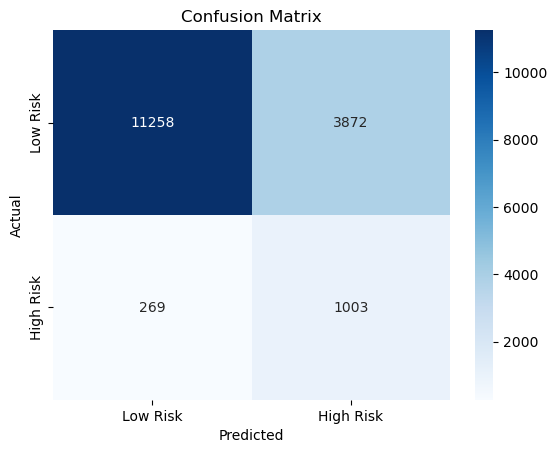

In [1146]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk','High Risk'],
            yticklabels=['Low Risk','High Risk'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

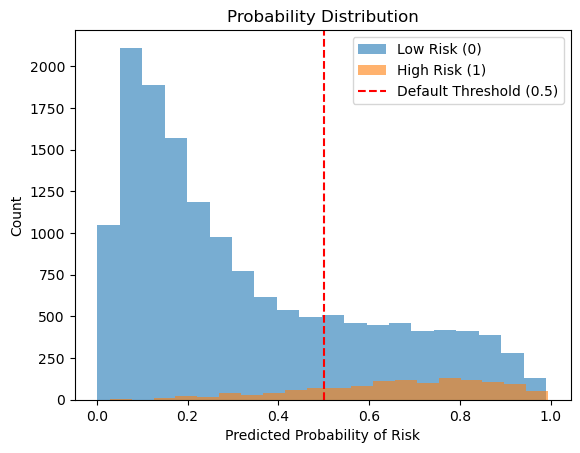

In [1147]:
# Logistic Regression Probability Distribution

y_prob = model.predict_proba(X_test)[:, 1]

plt.hist(y_prob[y_test == 0], bins=20, alpha=0.6, label="Low Risk (0)")
plt.hist(y_prob[y_test == 1], bins=20, alpha=0.6, label="High Risk (1)")

plt.axvline(0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
plt.legend()
plt.xlabel("Predicted Probability of Risk")
plt.ylabel("Count")
plt.title("Probability Distribution")
plt.show()


In [1148]:
# As per the graph, the optimal threshold is 0.30, which captures more of the high-risk accounts while Maintining a Good accuracy.

y_prob = model.predict_proba(X_test)[:, 1]

y_pred = np.where(y_prob >= 0.30, 1, 0)

print(metrics.confusion_matrix(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))
print(f'Accuracy---', metrics.accuracy_score(y_test, y_pred))
print(f'ROC_AUC Score---', metrics.roc_auc_score(y_test, y_prob))

[[8813 6317]
 [  80 1192]]
              precision    recall  f1-score   support

           0       0.99      0.58      0.73     15130
           1       0.16      0.94      0.27      1272

    accuracy                           0.61     16402
   macro avg       0.57      0.76      0.50     16402
weighted avg       0.93      0.61      0.70     16402

Accuracy--- 0.6099865870015851
ROC_AUC Score--- 0.8330922882190823


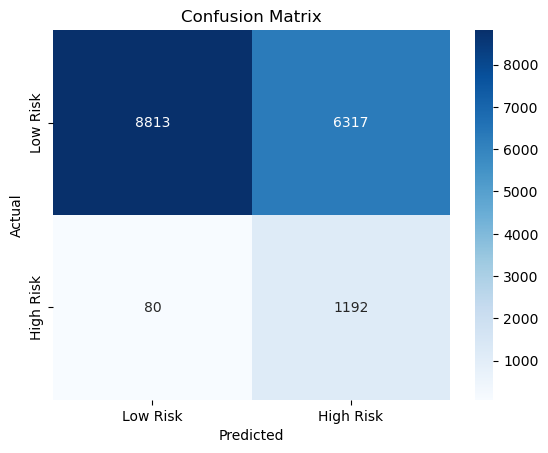

In [1149]:
cm = metrics.confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk','High Risk'],
            yticklabels=['Low Risk','High Risk'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

* model is catching most of the high risk correctly (1192), very few are missed (80) which is good
* but it is also flagging a lot of low risk as high risk (6317), so model is slightly aggressive on risk side

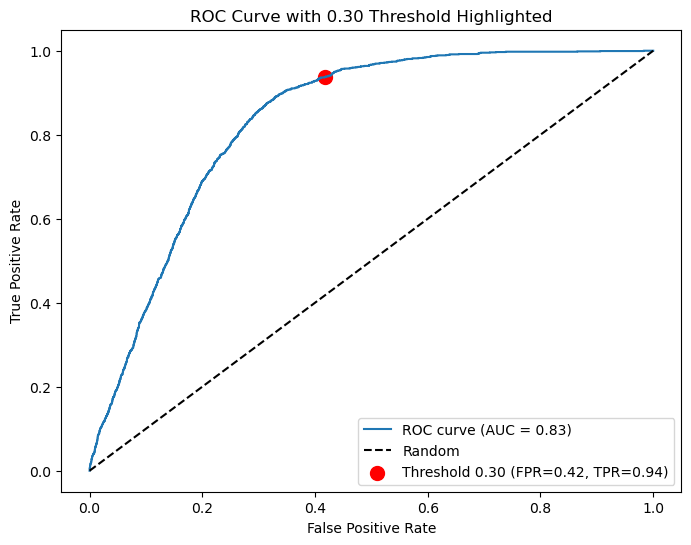

In [1189]:
# ROC_AUC Curve

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_prob, pos_label=1)
roc_auc = metrics.auc(fpr, tpr)

# Find the index of the threshold closest to 0.30
idx = np.argmin(np.abs(thresholds - 0.30))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')

# Highlight the 0.30 threshold point
plt.scatter(fpr[idx], tpr[idx], color='red', s=100, label=f'Threshold 0.30 (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with 0.30 Threshold Highlighted')
plt.legend()
plt.show()

In [ ]:
# Coefficients Interpretation
coef_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": model.coef_[0]
})

coef_df.sort_values(by='Coefficient', ascending=False).reset_index(drop=True).round(4)

,Variable,Coefficient
0,LoanMonthsSinceOrigination,0.1012
1,InquiriesLast6Months,0.0622
2,ListingCategory (numeric),0.0516
3,TotalInquiries,0.0468
4,Term,0.0348
5,CurrentDelinquencies,0.0222
6,ews_score,0.0153
7,ews_flag,0.0051
8,MonthlyLoanPayment,0.0046
9,DebtToIncomeRatio,0.0028


* loan age and recent inquiries are strongest positive drivers, so as loans get older and inquiries increase, risk goes up
* credit quality variables like prosper rating, prosper score and credit score are negative, so better credit profile clearly reduces risk
* overall model is behaving logically, high activity + weaker credit → higher risk, stronger credit → lower risk

In [1152]:
# Adding the predicted probabilities to the original data
x_train_PD_data = X_train.copy()
x_test_PD_data = X_test.copy()

x_train_PD_data['PD_prob'] = model.predict_proba(X_train)[:,1]
x_test_PD_data['PD_prob']  = model.predict_proba(X_test)[:,1]

In [1153]:
# Combining the train and test data to create a single dataframe and adding the predicted probabilities
combined_train_test = pd.concat([x_train_PD_data, x_test_PD_data], axis=0).sort_index()

# Imported_data is raw dataset before transformation
combined_pd = data.join(combined_train_test[['PD_prob']], how='left')

combined_pd.to_csv('PD_Model_Data.csv', index=True)

# Expected Loss (EL) Analysis

In [1190]:
# Importing the data
loan = pd.read_csv('PD_Model_Data.csv')

In [1191]:
loan = loan.set_index("LoanNumber")
loan

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,DateCreditPulled,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors,Loan_Org_year,Loan_Org_month,PD_prob
LoanNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
134815,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,0.07960,0.0249,0.05470,6.0,A,7.0,2,CO,Professional,Employed,44.0,False,False,NaN,2014-02-27 08:28:14,680.0,699.0,1996-03-18 00:00:00,14.0,14.0,29.0,13,389.0,3.0,5.0,0.0,0.0,0.0,1.0,0.0,3989.0,0.21,10266.0,29.0,1.00,2.0,0.18,"$50,000-74,999",True,6125.000000,9E3B37071505919926B1D82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,10000,2014-03-03,Q1 2014,1D13370546739025387B2F4,318.93,0.0000,0.00,0.0000,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1,2014,3,0.066131
77296,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,0.08490,0.0249,0.06000,6.0,A,9.0,16,GA,Skilled Labor,Employed,113.0,True,False,NaN,2012-10-22 11:02:32,800.0,819.0,1983-02-28 00:00:00,5.0,5.0,29.0,7,115.0,0.0,1.0,4.0,10056.0,14.0,0.0,0.0,1444.0,0.04,30754.0,26.0,0.76,0.0,0.15,"$25,000-49,999",True,2875.000000,A0393664465886295619C51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,16,10000,2012-11-01,Q4 2012,9ADE356069835475068C6D2,321.45,5143.2000,4091.09,1052.1100,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158,2012,11,0.286882
102670,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,0.18316,0.0925,0.09066,3.0,D,4.0,2,MN,Executive,Employed,44.0,True,False,NaN,2013-09-14 18:38:44,680.0,699.0,2004-02-20 00:00:00,19.0,19.0,49.0,6,220.0,1.0,9.0,0.0,0.0,0.0,0.0,0.0,6193.0,0.81,695.0,39.0,0.95,2.0,0.26,"$100,000+",True,9583.333333,A180369302188889200689E,1.0,11.0,11.0,0.0,0.0,11000.0,9947.90,NaN,0,NaN,6,15000,2013-09-20,Q3 2013,36CE356043264555721F06C,563.97,2819.8500,1563.22,1256.6300,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20,2013,9,0.176674
123257,0F05359734824199381F61D,1074836,2013-12-14 08:26:37.093000000,NaN,60,Current,NaN,0.15425,0.1314,0.1214,0.11567,0.0449,0.07077,5.0,B,10.0,1,NM,Professional,Employed,82.0,True,False,NaN,2013-12-14 08:26:40,740.0,759.0,1973-03-01 00:00:00,21.0,17.0,49.0,13,1410.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,62999.0,0.39,86509.0,47.0,1.00,0.0,0.36,"$100,000+",True,8333.333333,C3D63702273952547E79520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,3,15000,2013-12-24,Q4 2013,874A3701157341738DE458F,342.37,679.3400,351.89,327.4500,-25.33,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1,2013,12,0.032748
88353,0F0A3

In [1192]:
loan['LoanOriginationDate'] = pd.to_datetime(loan['LoanOriginationDate'])
loan['Loan_org_year'] = loan['LoanOriginationDate'].dt.year
loan['Loan_org_month'] = loan['LoanOriginationDate'].dt.month

In [1193]:
# Vintage cohort
loan['vintage_cohort'] = loan['LoanOriginationDate'].dt.to_period('Q')

# LGD
loan['LGD_net'] = (
    loan['LP_NetPrincipalLoss'] / loan['LoanOriginalAmount']
).clip(0, 1)

# EAD
loan['EAD'] = (
    loan['LoanOriginalAmount'] - loan['LP_CustomerPrincipalPayments']
).clip(0)


In [ ]:
# EWS score
loan['ews_score'] = (
    (loan['DebtToIncomeRatio']      > 0.35).astype(int) +
    (loan['BankcardUtilization']    > 0.75).astype(int) +
    (loan['InquiriesLast6Months']   >= 4  ).astype(int) +
    (loan['CurrentDelinquencies']   >= 1  ).astype(int) +
    (loan['CreditScoreRangeLower']  < 600 ).astype(int)
)

loan['ews_flag'] = (loan['ews_score'] >= 2).astype(int)

In [ ]:
# Expected Loss (EL) Calculation
loan['EL'] = loan['PD_prob'] * loan['LGD_net'] * loan['EAD']

In [1196]:
loan.head()

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,DateCreditPulled,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors,Loan_Org_year,Loan_Org_month,PD_prob,Loan_org_year,Loan_org_month,vintage_cohort,LGD_net,EAD,ews_score,ews_flag,EL
LoanNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
134815,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,0.07960,0.0249,0.05470,6.0,A,7.0,2,CO,Professional,Employed,44.0,False,False,NaN,2014-02-27 08:28:14,680.0,699.0,1996-03-18 00:00:00,14.0,14.0,29.0,13,389.0,3.0,5.0,0.0,0.0,0.0,1.0,0.0,3989.0,0.21,10266.0,29.0,1.00,2.0,0.18,"$50,000-74,999",True,6125.000000,9E3B37071505919926B1D82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,10000,2014-03-03,Q1 2014,1D13370546739025387B2F4,318.93,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1,2014,3,0.066131,2014,3,2014Q1,0.0,10000.00,0,0,0.0
77296,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,0.08490,0.0249,0.06000,6.0,A,9.0,16,GA,Skilled Labor,Employed,113.0,True,False,NaN,2012-10-22 11:02:32,800.0,819.0,1983-02-28 00:00:00,5.0,5.0,29.0,7,115.0,0.0,1.0,4.0,10056.0,14.0,0.0,0.0,1444.0,0.04,30754.0,26.0,0.76,0.0,0.15,"$25,000-49,999",True,2875.000000,A0393664465886295619C51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,16,10000,2012-11-01,Q4 2012,9ADE356069835475068C6D2,321.45,5143.20,4091.09,1052.11,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158,2012,11,0.286882,2012,11,2012Q4,0.0,5908.91,1,0,0.0
102670,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,0.18316,0.0925,0.09066,3.0,D,4.0,2,MN,Executive,Employed,44.0,True,False,NaN,2013-09-14 18:38:44,680.0,699.0,2004-02-20 00:00:00,19.0,19.0,49.0,6,220.0,1.0,9.0,0.0,0.0,0.0,0.0,0.0,6193.0,0.81,695.0,39.0,0.95,2.0,0.26,"$100,000+",True,9583.333333,A180369302188889200689E,1.0,11.0,11.0,0.0,0.0,11000.0,9947.9,NaN,0,NaN,6,15000,2013-09-20,Q3 2013,36CE356043264555721F06C,563.97,2819.85,1563.22,1256.63,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20,2013,9,0.176674,2013,9,2013Q3,0.0,13436.78,1,0,0.0
123257,0F05359734824199381F61D,1074836,2013-12-14 08:26:37.093000000,NaN,60,Current,NaN,0.15425,0.1314,0.1214,0.11567,0.0449,0.07077,5.0,B,10.0,1,NM,Professional,Employed,82.0,True,False,NaN,2013-12-14 08:26:40,740.0,759.0,1973-03-01 00:00:00,21.0,17.0,49.0,13,1410.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,62999.0,0.39,86509.0,47.0,1.00,0.0,0.36,"$100,000+",True,8333.333333,C3D63702273952547E79520,NaN,NaN,

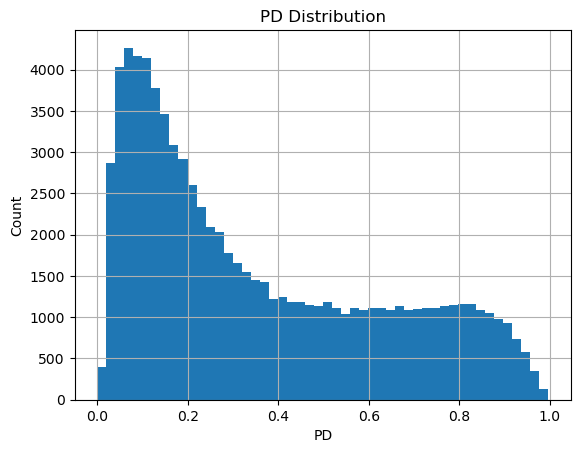

In [1197]:
loan["PD_prob"].hist(bins=50)
plt.title("PD Distribution")
plt.xlabel("PD")
plt.ylabel("Count")
plt.show()

In [ ]:
# DPD Bucket calculation
def dpd_bucket(dpd):
    if dpd == 0:
        return "Current"
    elif dpd <= 30:
        return "1-30"
    elif dpd <= 60:
        return "31-60"
    elif dpd <= 90:
        return "61-90"
    else:
        return "90+"

loan["dpd_bucket"] = loan["LoanCurrentDaysDelinquent"].apply(dpd_bucket)

In [ ]:
# DPD Bucket Summary

dpd_summary = loan.groupby("dpd_bucket").agg(
    accounts=("PD_prob", "count"),
    avg_pd=("PD_prob", "mean"),
    total_el=("EL", "sum")
).reset_index().round(2)

dpd_summary

,dpd_bucket,accounts,avg_pd,total_el
0,1-30,1067,0.44,0.00
1,31-60,364,0.43,0.00
2,61-90,330,0.45,0.00
3,90+,6334,0.67,16234540.29
4,Current,73911,0.33,0.00


* 90+ dpd bucket is clearly the riskiest, avg pd is very high (0.67) and it is driving almost entire loss in the portfolio
* current and lower dpd buckets have lower pd and almost no loss, so risk is highly concentrated in already delinquent accounts

In [ ]:
# PD Bucket calculation
loan["PD_bucket"] = pd.cut(
    loan["PD_prob"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

In [1227]:
pd_summary = loan.groupby("PD_bucket").agg(
    accounts=("PD_prob", "count"),
    exposure=("LoanOriginalAmount", "sum"),
    total_el=("EL", "sum")
).reset_index().round(2)

pd_summary["el_share"] = pd_summary["total_el"] / loan["EL"].sum()
pd_summary["account_share"] = pd_summary["accounts"] / pd_summary["accounts"].sum()

pd_summary

,PD_bucket,accounts,exposure,total_el,el_share,account_share
0,Very Low,33230,404844820,182924.02,0.011268,0.405214
1,Low,18130,155933542,1004455.89,0.061872,0.221081
2,Medium,11477,82041041,3340023.99,0.205736,0.139953
3,High,11184,70288915,6474793.64,0.398828,0.136380
4,Very High,7985,39213867,5232342.75,0.322297,0.097371


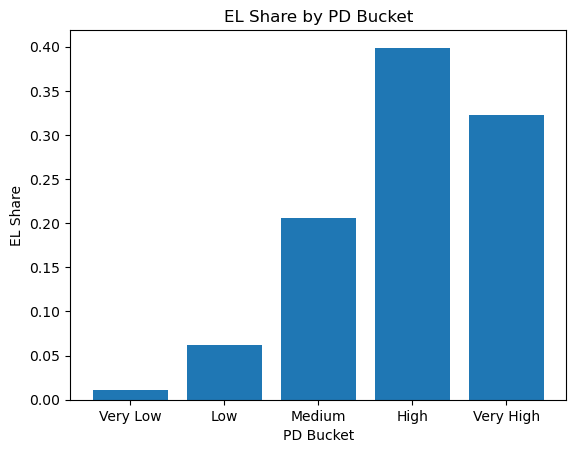

In [ ]:

plt.bar(pd_summary["PD_bucket"], pd_summary["el_share"])

plt.title("EL Share by PD Bucket")
plt.xlabel("PD Bucket")
plt.ylabel("EL Share")

plt.show()

* very low and low pd buckets have most of the accounts and exposure but contribute very little to loss
* high and very high pd buckets have fewer accounts but drive most of the loss, so risk is clearly concentrated in smaller risky segments
* medium bucket is also important as it is starting to contribute meaningful loss and can move to high risk

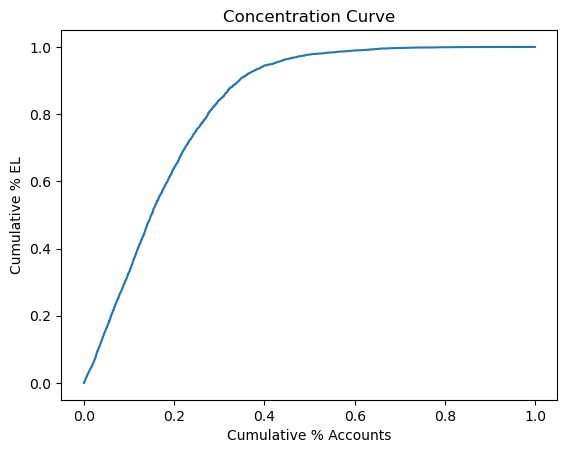

In [1205]:
top = loan.sort_values("PD_prob", ascending=False).reset_index(drop=True)
top["cum_el"] = top["EL"].cumsum()
top["cum_el_pct"] = top["cum_el"] / loan["EL"].sum()

top["cum_accounts_pct"] = (top.index + 1) / len(top)
import matplotlib.pyplot as plt

plt.plot(top["cum_accounts_pct"], top["cum_el_pct"])

plt.title("Concentration Curve")
plt.xlabel("Cumulative % Accounts")
plt.ylabel("Cumulative % EL")

plt.show()

* a small portion of accounts is contributing most of the expected loss, clear concentration of risk and around first 20–30% accounts are driving majority of the loss, so risk is not evenly spread rest of the portfolio has very low impact on loss, so focus should be on top risky segment


In [1206]:
vintage = loan.groupby(["Loan_Org_year", "Loan_Org_month"]).agg(
    total_el=("EL", "sum")
).round(2).reset_index()

vintage_pivot = vintage.pivot(
    index="Loan_Org_month",
    columns="Loan_Org_year",
    values="total_el"
)

vintage_pivot.style.background_gradient(cmap='Blues')

Loan_Org_year,2010,2011,2012,2013,2014
Loan_Org_month,,,,,
1,92957.050000,215255.360000,729999.640000,146535.780000,0.000000
2,93064.980000,242380.960000,719937.590000,85742.010000,0.000000
3,72000.460000,358819.730000,842175.630000,99284.250000,0.000000
4,141515.690000,420926.210000,778283.720000,137550.360000,nan
5,128639.100000,603232.400000,803028.990000,141325.480000,nan
6,150221.090000,578579.140000,847371.980000,114604.720000,nan
7,97559.100000,442410.970000,899904.370000,28523.460000,nan
8,143377.150000,663476.840000,676243.390000,8724.520000,nan
9,143245.510000,555900.930000,619152.530000,1714.650000,nan


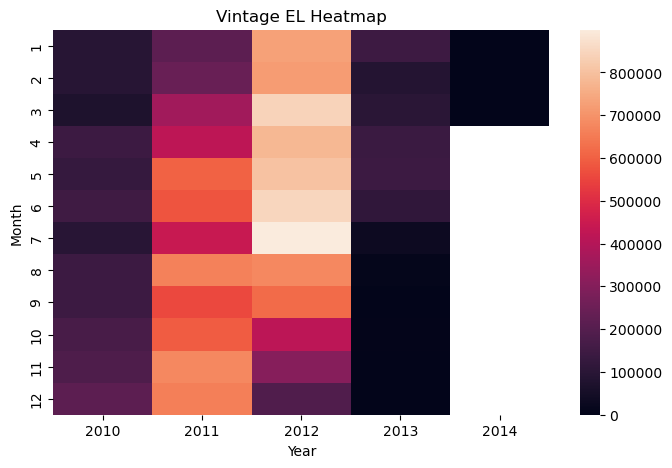

In [1207]:
plt.figure(figsize=(8,5))
sns.heatmap(vintage_pivot)

plt.title("Vintage EL Heatmap")
plt.xlabel("Year")
plt.ylabel("Month")

plt.show()

* 2012 vintages are showing highest expected loss across almost all months, so this year looks like the riskiest cohort
* 2011 also has high losses but still lower than 2012, while 2010 and 2013 are relatively lower
* loss increases in middle months and then starts dropping, so risk seems to peak after some time and then reduce
* 2014 has no data yet, so cannot conclude anything for that year

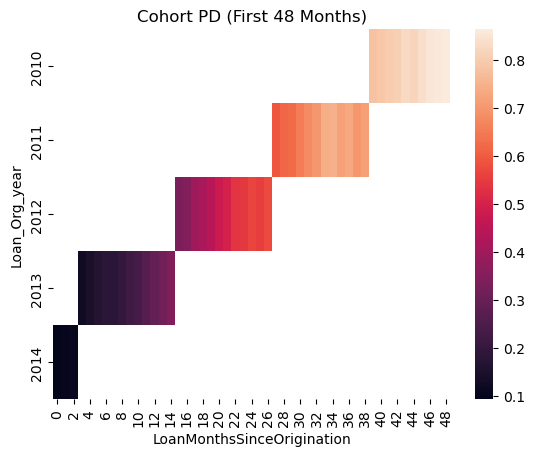

In [1228]:
cohort = loan.groupby(
    ["Loan_Org_year", "LoanMonthsSinceOrigination"]
).agg(
    avg_pd=("PD_prob", "mean")
).reset_index()
cohort_pivot = cohort.pivot(
    index="Loan_Org_year",
    columns="LoanMonthsSinceOrigination",
    values="avg_pd"
)


cohort_filtered = cohort[cohort["LoanMonthsSinceOrigination"] <= 48]

cohort_pivot = cohort_filtered.pivot(
    index="Loan_Org_year",
    columns="LoanMonthsSinceOrigination",
    values="avg_pd"
)

sns.heatmap(cohort_pivot)
plt.title("Cohort PD (First 48 Months)")
plt.show()

* pd is clearly increasing as loans age, so risk builds up over time
* older vintages like 2010 and 2011 reach much higher pd compared to newer ones
* 2012 shows faster rise in pd compared to 2013, so that cohort looks riskier
* newer cohorts (2013, 2014) are still in early stage, so risk is low now but can increase later

   ews_flag  accounts  avg_pd
0         0     70450    0.34
1         1     11556    0.44


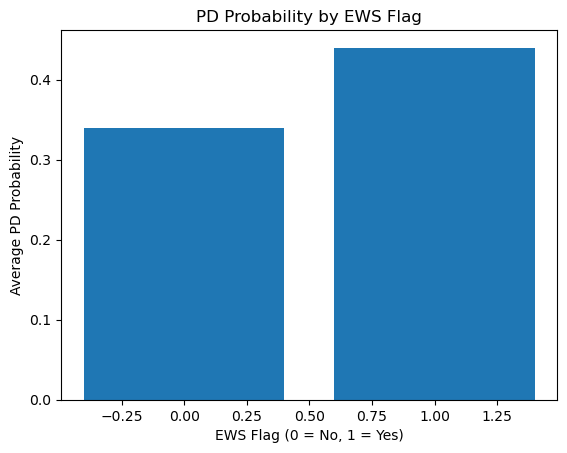

In [ ]:
# EWS Analysis

ews = loan.groupby("ews_flag").agg(
    accounts=("PD_prob", "count"),
    avg_pd=("PD_prob", "mean")
).reset_index().round(2)

print(ews)

plt.bar(ews["ews_flag"], ews["avg_pd"])
plt.title("PD Probability by EWS Flag")
plt.xlabel("EWS Flag (0 = No, 1 = Yes)")
plt.ylabel("Average PD Probability")
plt.show()

* accounts with ews flag have clearly higher pd (~0.44) compared to non-ews (~0.34), so ews is capturing higher risk segment
* majority of accounts are still non-ews, but flagged group shows noticeably higher default probability, so it is a useful early risk indicator

  EmploymentStatus  accounts  total_el
0         Employed     66586      0.32
1        Full-time      6155      0.71
2     Not employed       625      0.71
3            Other      3742      0.37
4        Part-time       197      0.85
5          Retired       329      0.73
6    Self-employed      4372      0.36


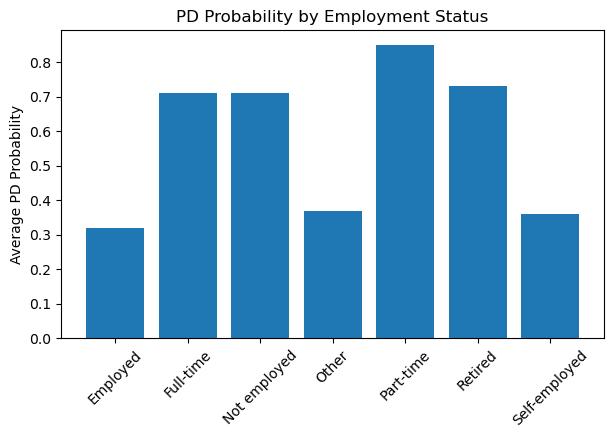

In [1210]:
emp = loan.groupby("EmploymentStatus").agg(
    accounts=("PD_prob", "count"),
    total_el=("PD_prob", "mean")
).reset_index().round(2)

print(emp)

plt.figure(figsize=(7,4))

plt.bar(emp["EmploymentStatus"], emp["total_el"])
plt.xticks(rotation=45)

plt.title("PD Probability by Employment Status")
plt.ylabel("Average PD Probability")
plt.show()

  inq_bucket  accounts  total_el
0        0-1     62875      0.33
1        2-3     14558      0.42
2        4-5      3387      0.51
3         6+      1107      0.62


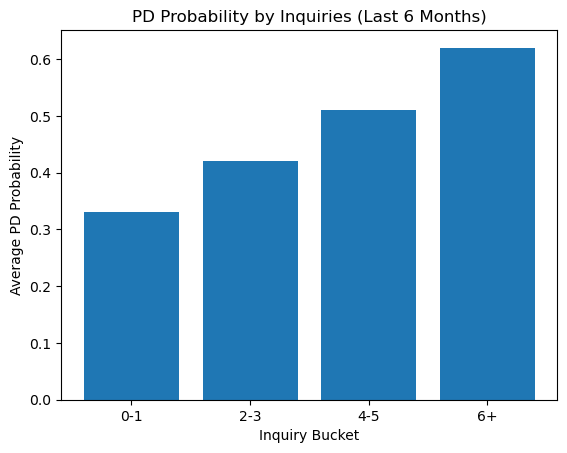

In [1211]:
loan["inq_bucket"] = pd.cut(
    loan["InquiriesLast6Months"],
    bins=[-1, 1, 3, 5, 10],
    labels=["0-1", "2-3", "4-5", "6+"]
)

inq = loan.groupby("inq_bucket").agg(
    accounts=("PD_prob", "count"),
    total_el=("PD_prob", "mean")
).reset_index().round(2)

print(inq)

plt.bar(inq["inq_bucket"], inq["total_el"])

plt.title("PD Probability by Inquiries (Last 6 Months)")
plt.xlabel("Inquiry Bucket")
plt.ylabel("Average PD Probability")

plt.show()

* as inquiries increase, pd clearly increases, so higher credit activity is linked to higher risk
* 6+ inquiries segment has the highest pd 0.62, so this group is very risky
* majority of accounts are in low inquiry bucket, but smaller high inquiry segments are driving higher risk

# Portfolio Stress Testing

In [1212]:
stressed = X_test.copy()

# 🔻 Increase delinquency behavior
stressed["CurrentDelinquencies"] = stressed["CurrentDelinquencies"] + 2
stressed["DelinquenciesLast7Years"] = stressed["DelinquenciesLast7Years"] + 3
stressed['Term'] = stressed['Term'] + 6

# 🔻 Reduce good credit history
stressed["TradesNeverDelinquent (percentage)"] = (
    stressed["TradesNeverDelinquent (percentage)"] * 0.8
)

# 🔻 Increase credit stress
stressed["BankcardUtilization"] = stressed["BankcardUtilization"] * 1.7
stressed["DebtToIncomeRatio"] = stressed["DebtToIncomeRatio"] * 1.5
stressed["CreditScoreRangeLower"] = stressed["CreditScoreRangeLower"] - 50

# 🔻 Slight increase in credit demand
stressed["InquiriesLast6Months"] = stressed["InquiriesLast6Months"] + 2

In [1213]:
# Base PD
stressed["PD_base"] = loan["PD_prob"]

# Stressed PD (only model features)
stressed["PD_stress"] = model.predict_proba(
    stressed[X_test.columns]
)[:, 1]

In [1214]:
print(X_test.shape)
print(stressed.shape)

(16402, 22)
(16402, 24)


In [1215]:
print(X_test.columns)
print(stressed.columns)

Index(['Term', 'LoanMonthsSinceOrigination', 'LoanOriginalAmount',
       'MonthlyLoanPayment', 'ProsperRating (numeric)', 'ProsperScore',
       'CreditScoreRangeLower', 'DebtToIncomeRatio', 'BankcardUtilization',
       'InquiriesLast6Months', 'CurrentDelinquencies',
       'DelinquenciesLast7Years', 'RevolvingCreditBalance', 'TotalInquiries',
       'TradesNeverDelinquent (percentage)', 'PublicRecordsLast10Years',
       'StatedMonthlyIncome', 'ListingCategory (numeric)', 'ews_score',
       'ews_flag', 'EmploymentStatus_enc', 'Income_enc'],
      dtype='object')
Index(['Term', 'LoanMonthsSinceOrigination', 'LoanOriginalAmount',
       'MonthlyLoanPayment', 'ProsperRating (numeric)', 'ProsperScore',
       'CreditScoreRangeLower', 'DebtToIncomeRatio', 'BankcardUtilization',
       'InquiriesLast6Months', 'CurrentDelinquencies',
       'DelinquenciesLast7Years', 'RevolvingCreditBalance', 'TotalInquiries',
       'TradesNeverDelinquent (percentage)', 'PublicRecordsLast10Years',
      

In [1216]:
stressed["EAD"] = loan.loc[stressed.index, "EAD"]
stressed["PD_base"] = loan.loc[stressed.index, "PD_prob"]
stressed["LGD_net"] = loan.loc[stressed.index, "LGD_net"]

stressed["EL_base"] = stressed["PD_base"] * stressed["LGD_net"] * stressed["EAD"]

In [1217]:
# Baseline
stressed["EL_base"] = (
    stressed["PD_base"] * stressed["LGD_net"] * stressed["EAD"]
)

# Stress
stressed["Stressed_EL"] = (
    stressed["PD_stress"] * stressed["LGD_net"] * stressed["EAD"]
)

# Change
stressed["Stressed_EL_change"] = (
    stressed["Stressed_EL"] - stressed["EL_base"]
)

stressed["Stressed_EL_percentage"] = (
    stressed["Stressed_EL_change"] / stressed["EL_base"]
) * 100

In [1218]:
stressed

,Term,LoanMonthsSinceOrigination,LoanOriginalAmount,MonthlyLoanPayment,ProsperRating (numeric),ProsperScore,CreditScoreRangeLower,DebtToIncomeRatio,BankcardUtilization,InquiriesLast6Months,CurrentDelinquencies,DelinquenciesLast7Years,RevolvingCreditBalance,TotalInquiries,TradesNeverDelinquent (percentage),PublicRecordsLast10Years,StatedMonthlyIncome,ListingCategory (numeric),ews_score,ews_flag,EmploymentStatus_enc,Income_enc,PD_base,PD_stress,EAD,LGD_net,EL_base,Stressed_EL,Stressed_EL_change,Stressed_EL_percentage
LoanNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
48957,42,35,4000,172.56,1.0,4.0,610.0,0.255,1.411,4.0,3.0,14.0,17179.0,7.0,0.552,1.0,9583.333333,2,2,1,4,110000,0.761420,0.847183,2009.70,0.502425,768.823239,855.420957,86.597718,11.263671
125221,42,2,10000,370.11,4.0,4.0,610.0,0.450,0.646,3.0,2.0,26.0,5425.0,10.0,0.608,1.0,3500.000000,2,0,0,4,37500,0.207245,0.312882,9797.21,0.000000,0.000000,0.000000,0.000000,NaN
124022,42,3,15000,526.25,4.0,8.0,630.0,0.645,1.496,2.0,2.0,3.0,62379.0,4.0,0.800,0.0,10000.000000,1,2,1,4,110000,0.057962,0.096571,14327.86,0.000000,0.000000,0.000000,0.000000,NaN
124386,42,2,15000,483.30,6.0,10.0,670.0,0.585,0.986,2.0,2.0,3.0,80930.0,0.0,0.800,0.0,5833.333333,1,1,0,4,62500,0.040235,0.067989,14270.73,0.000000,0.000000,0.000000,0.000000,NaN
93903,66,9,25000,676.19,4.0,4.0,650.0,0.150,1.632,4.0,2.0,3.0,240058.0,6.0,0.800,0.0,33333.333333,1,1,0,4,110000,0.140894,0.221584,23030.05,0.000000,0.000000,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122076,42,3,2000,75.14,3.0,4.0,590.0,0.060,0.000,2.0,2.0,3.0,285.0,4.0,0.680,1.0,3291.666667,7,0,0,4,37500,0.191441,0.292362,1919.68,0.000000,0.000000,0.000000,0.000000,NaN
129672,42,1,15000,493.86,6.0,6.0,630.0,0.555,1.377,2.0,2.0,3.0,9624.0,1.0,0.752,0.0,4083.333333,1,2,1,4,37500,0.088104,0.143764,14637.20,0.000000,0.000000,0.000000,0.000000,NaN
133879,42,1,5000,178.89,4.0,3.0,670.0,0.375,1.258,3.0,2.0,3.0,29500.0,8.0,0.800,0.0,5500.000000,6,0,0,3,62500,0.120734,0.192689,5000.00,0.000000,0.000000,0.000000,0.000000,NaN


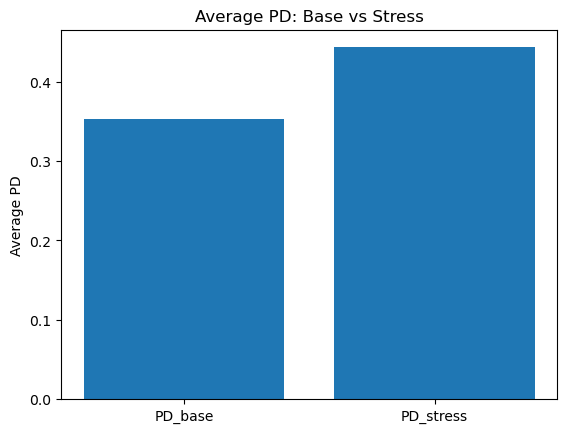

In [1219]:
plt.bar(['PD_base', 'PD_stress'], [
    stressed["PD_base"].mean(),
    stressed["PD_stress"].mean()
])
plt.title("Average PD: Base vs Stress")
plt.ylabel("Average PD")
plt.show()

In [1220]:
print("Portfolio Summary")

baseline_EL = stressed["EL_base"].sum()
stress_EL = stressed["Stressed_EL"].sum()

print("Baseline EL:", baseline_EL)
print("Stress EL:", stress_EL)
print("EL Change:", stress_EL - baseline_EL)

print("EL Change %:", ((stress_EL - baseline_EL) / baseline_EL) * 100)

Portfolio Summary
Baseline EL: 3264349.9211058076
Stress EL: 3806298.795502723
EL Change: 541948.8743969155
EL Change %: 16.602045966117775


* under stress scenario expected loss increases by around 16.6%, so portfolio is sensitive but not overly fragile
* increase is driven by worsening delinquency (+2 current, +3 past), higher utilization and dti, lower credit score and reduced good repayment history
* overall portfolio looks stable, but risk can rise noticeably when borrower behavior and credit conditions deteriorate

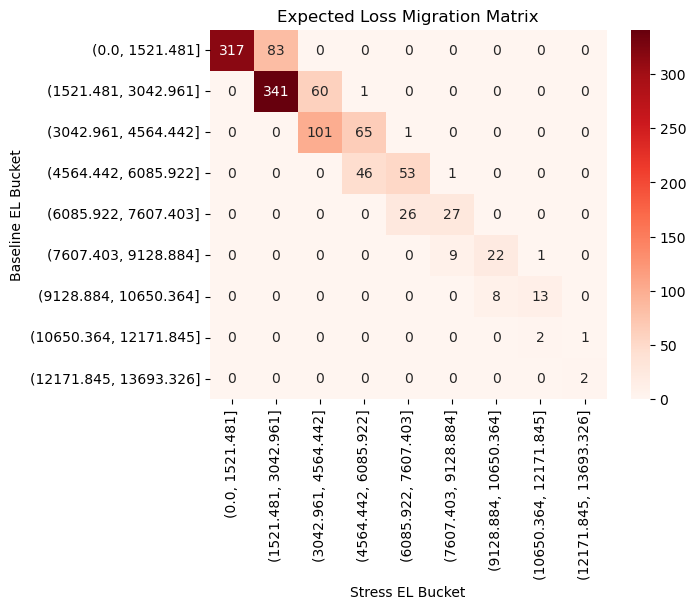

In [1221]:
# Migration Matrix

bins = np.linspace(
    stressed["EL_base"].min(),
    stressed["Stressed_EL"].max(),
    10
)

stressed["baseline_bucket"] = pd.cut(stressed["EL_base"], bins)
stressed["stress_bucket"] = pd.cut(stressed["Stressed_EL"], bins)

migration = pd.crosstab(
    stressed["baseline_bucket"],
    stressed["stress_bucket"]
)

plt.figure()

sns.heatmap(migration, annot=True, fmt="d", cmap="Reds")

plt.title("Expected Loss Migration Matrix")
plt.xlabel("Stress EL Bucket")
plt.ylabel("Baseline EL Bucket")

plt.show()

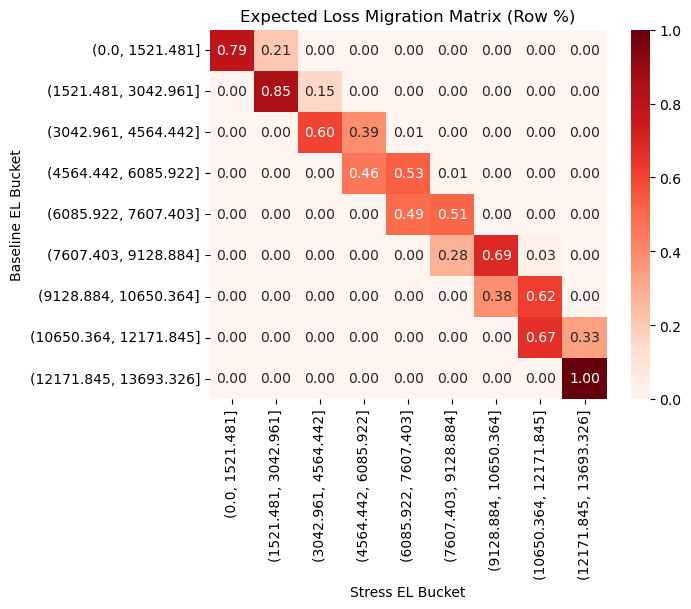

In [1222]:
migration_pct = migration.div(migration.sum(axis=1), axis=0)
sns.heatmap(migration_pct, annot=True, fmt=".2f", cmap="Reds")
plt.title("Expected Loss Migration Matrix (Row %)")
plt.xlabel("Stress EL Bucket")
plt.ylabel("Baseline EL Bucket")                
plt.show()

* most accounts are staying in same or nearby buckets, so portfolio is fairly stable even under stress
* there is clear movement towards higher el buckets, so risk is increasing but in a gradual way
* very few accounts are moving to lower buckets, so overall direction is deterioration, not improvement
* higher el buckets are getting more populated under stress, showing risk concentration increasing

In [1236]:
total_el = stressed["Stressed_EL"].sum()

stressed["EL_share"] = stressed["Stressed_EL"] / total_el

top20 = stressed.sort_values("Stressed_EL_change", ascending=False).head(20)

top20[[
    "PD_base", "PD_stress", "EAD", "LGD_net", "Stressed_EL", "EL_share"
]].style.background_gradient(cmap="Reds").format({
    "PD_base": "{:.4f}",
    "PD_stress": "{:.4f}",
    "EAD": "{:.2f}",
    "LGD_net": "{:.4f}",
    "Stressed_EL": "{:.2f}",
    "EL_share": "{:.2%}"
})

,PD_base,PD_stress,EAD,LGD_net,Stressed_EL,EL_share
LoanNumber,,,,,,
73329,0.3867,0.5237,23459.07,0.9384,11529.06,0.30%
70460,0.4876,0.6241,22049.68,0.8820,12137.00,0.32%
68558,0.3287,0.4607,22131.96,0.8853,9026.05,0.24%
58873,0.5033,0.6386,19435.29,0.9718,12060.91,0.32%
89148,0.2192,0.3277,23857.17,0.9543,7460.73,0.20%
85866,0.4117,0.5485,16846.57,0.9627,8894.70,0.23%
60086,0.5646,0.6933,20604.69,0.8242,11774.49,0.31%
76604,0.2382,0.3523,19518.16,0.9759,6711.39,0.18%
72330,0.6009,0.7242,18297.23,0.9149,12122.70,0.32%


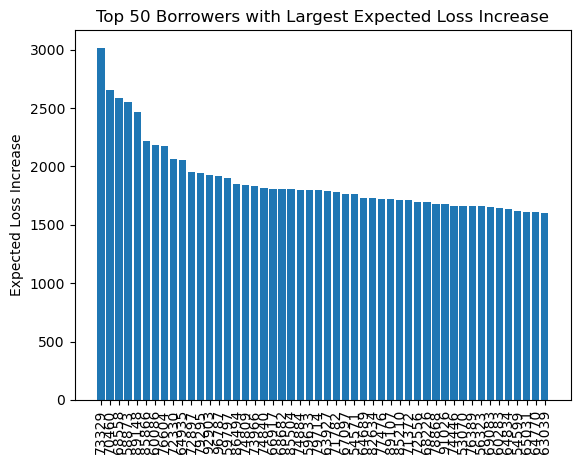

In [ ]:
# Top Borrowers woth Largest Expected Loss Increase

top_risk = stressed.sort_values("Stressed_EL_change", ascending=False).head(50)

plt.figure()

plt.bar(range(len(top_risk)), top_risk["Stressed_EL_change"])

plt.xticks(range(len(top_risk)), top_risk.index, rotation=90)

plt.ylabel("Expected Loss Increase")
plt.title("Top 50 Borrowers with Largest Expected Loss Increase")

plt.show()

* top borrowers individually contribute small share (~0.15% to 0.32%), but together they form a significant portion of total loss
* all these accounts have high pd increase, high exposure and very high lgd, which is driving the loss
* no single borrower dominates, but risk is concentrated across a small group of high-risk accounts
* stress is pushing already risky borrowers into higher loss impact zone